# 16 · 토스 후속 행동 라벨 후보 EDA

**한 줄 답:** 토스 후속 행동 8대는 그냥 “돌아왔다”보다 `새 영역 도달`·`퀘스트/교류`·`낚시/바다` 같은 게임 안 유도 목표로 쪼개 볼 수 있다. 다만 표본이 46대, 후속 행동 양성이 8대라 모델 학습은 아직 하지 않는다.

**이번 게이트의 질문:** 15번에서 보류한 라벨을 그대로 두고, 다음 네 가지만 본다.

1. 10분 이후 행동을 영역별 목표로 쪼갠다.
2. 첫 10분 행동 6회 이상 집단 안을 본다.
3. 후속 행동 8대가 특정 날짜·기기 꼬리에 몰렸는지 감사한다.
4. `새 영역 첫 도달` 라벨을 만든다.

**사전 기준:** 14·15번과 같은 46대 표본, 같은 양성 8대, 경계 위반 0이 유지되고, 각 후보 라벨의 양성 수와 세그먼트 편중을 문서화하면 통과. 모델 학습·AUC·피처 중요도는 실패로 본다.

## 1. 범위

- 원천은 BigQuery GA4 일별 export 2026-09-04~09-12(KST).
- 코호트는 첫 `platform='toss'`가 2026-09-04~09-11에 관측된 비베타 표식 기기이며, 24시간 라벨 창이 완전한 기기만 남긴다.
- 피처 구간은 첫 토스 이벤트 뒤 10분 미만, 라벨 구간은 10분 이후~24시간 미만이다.
- 저장 결과는 `D001` 같은 익명 라벨만 쓴다. 원시 `user_pseudo_id`는 SQL 내부 조인 키다.
- 행동 영역은 15번과 같은 5개다: 자연·채집, 낚시·바다, 퀘스트·교류, 제작·집, 고급 콘텐츠.

In [1]:
from pathlib import Path
import json
import os, sys

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parents[1]
os.chdir(ROOT)
sys.path.insert(0, str(ROOT / 'ml'))

from calm_ml import bq, report as R

R.setup()
SQL = ROOT / 'ml/sql/g3_toss_later_target_candidates.sql'
OUT = ROOT / 'ml/reports/g3_toss_later_targets_2026-09-15'
OUT.mkdir(parents=True, exist_ok=True)

AREA_LABELS = {
    'nature': '자연·채집',
    'fishing_sea': '낚시·바다',
    'quest_social': '퀘스트·교류',
    'craft_home': '제작·집',
    'advanced': '고급 콘텐츠',
}

def wilson(k, n, z=1.96):
    if n == 0:
        return 0, 0
    p = k / n
    den = 1 + z * z / n
    center = (p + z * z / (2 * n)) / den
    half = z * ((p * (1 - p) / n + z * z / (4 * n * n)) ** 0.5) / den
    return center - half, center + half


## 2. 실행 SQL

아래 SQL 하나가 1~4번 분석의 기준 표를 만든다. 15번 후보표와 같은 표본 정의를 쓰고, 이후 24시간 행동을 영역별·새 영역별로 추가 집계한다.

In [2]:
display(Markdown('```sql\n' + SQL.read_text(encoding='utf-8') + '\n```'))
d = bq.read_sql_file(str(SQL))
d.to_csv(OUT / 'later_target_candidates.csv', index=False)

assert len(d) == 46
assert int(d.later_active.sum()) == 8
assert int(d.feature_boundary_violations.sum()) == 0
assert int(d.label_boundary_violations.sum()) == 0
assert d.device_label.is_unique

display(pd.DataFrame({
    '항목': ['기기 수', '후속 행동 양성', '새 영역 도달', '퀘스트·교류 후속 도달', '낚시·바다 후속 도달', '자연·채집 후속 도달'],
    '값': [
        len(d),
        int(d.later_active.sum()),
        int(d.later_new_area.sum()),
        int(d.later_quest_social.sum()),
        int(d.later_fishing_sea.sum()),
        int(d.later_nature.sum()),
    ],
}))


```sql
-- G3 later-target candidate audit, NOT a model.
-- Goal: split the 10m-to-24h candidate label into intervention-relevant targets.
-- Cohort and time windows match g3_toss_device_feature_candidate.sql.
-- Raw GA4 device IDs are used only inside the query; output uses D001 labels.
WITH actions AS (
  SELECT action_name, area FROM UNNEST([
    STRUCT('chop_tree' AS action_name, 'nature' AS area),
    ('first_chop', 'nature'),
    ('plant_seed', 'nature'),
    ('water_crop', 'nature'),
    ('harvest_crop', 'nature'),
    ('forage_pick', 'nature'),
    ('mine_ore', 'nature'),
    ('fishing_cast', 'fishing_sea'),
    ('fishing_catch', 'fishing_sea'),
    ('fishing_miss', 'fishing_sea'),
    ('sea_cast', 'fishing_sea'),
    ('sea_catch', 'fishing_sea'),
    ('boat_start', 'fishing_sea'),
    ('npc_talk', 'quest_social'),
    ('quest_accept', 'quest_social'),
    ('quest_complete', 'quest_social'),
    ('gift_give', 'quest_social'),
    ('shop_sell', 'craft_home'),
    ('shop_buy', 'craft_home'),
    ('craft_item', 'craft_home'),
    ('place_decor', 'craft_home'),
    ('house_complete', 'craft_home'),
    ('house_expand', 'craft_home'),
    ('cooking_start', 'craft_home'),
    ('carve_start', 'craft_home'),
    ('mist_purify_start', 'advanced'),
    ('firefly_swing', 'advanced'),
    ('coop_build', 'advanced'),
    ('coop_feed', 'advanced'),
    ('coop_collect', 'advanced'),
    ('cafe_serve', 'advanced'),
    ('photo_capture', 'advanced'),
    ('dex_open', 'advanced'),
    ('album_open', 'advanced'),
    ('leaderboard_open', 'advanced')
  ])
),
base AS (
  SELECT
    user_pseudo_id,
    TIMESTAMP_MICROS(event_timestamp) AS ts,
    DATE(TIMESTAMP_MICROS(event_timestamp), 'Asia/Seoul') AS day,
    event_name,
    device.category AS device,
    geo.country AS country,
    traffic_source.source AS acquisition_source,
    (SELECT ep.value.string_value FROM UNNEST(event_params) ep
      WHERE ep.key = 'platform' LIMIT 1) AS platform,
    (SELECT ep.value.string_value FROM UNNEST(event_params) ep
      WHERE ep.key = 'method' LIMIT 1) AS login_method,
    (SELECT ep.value.string_value FROM UNNEST(event_params) ep
      WHERE ep.key = 'result' LIMIT 1) AS connect_result,
    (SELECT up.value.string_value FROM UNNEST(user_properties) up
      WHERE up.key = 'ab_variant' LIMIT 1) AS ab_variant
  FROM `calm-forest.analytics_547127440.events_*`
  WHERE _TABLE_SUFFIX NOT LIKE 'intraday_%'
    AND _TABLE_SUFFIX BETWEEN '20260904' AND '20260912'
    AND user_pseudo_id IS NOT NULL
),
toss AS (
  SELECT * FROM base WHERE platform = 'toss'
),
first_seen AS (
  SELECT
    user_pseudo_id,
    MIN(ts) AS first_ts,
    MIN(day) AS first_toss_day,
    LOGICAL_OR(REGEXP_CONTAINS(COALESCE(ab_variant, ''), r'^beta_[AB]$')) AS beta_marked
  FROM toss
  GROUP BY 1
),
eligible AS (
  SELECT *
  FROM first_seen
  WHERE NOT beta_marked
    AND first_ts < TIMESTAMP_SUB(TIMESTAMP('2026-09-13 00:00:00', 'Asia/Seoul'), INTERVAL 24 HOUR)
),
windowed AS (
  SELECT
    t.*,
    e.first_ts,
    e.first_toss_day,
    a.area,
    CASE
      WHEN t.ts >= e.first_ts
       AND t.ts < TIMESTAMP_ADD(e.first_ts, INTERVAL 10 MINUTE) THEN 'feature'
      WHEN t.ts >= TIMESTAMP_ADD(e.first_ts, INTERVAL 10 MINUTE)
       AND t.ts < TIMESTAMP_ADD(e.first_ts, INTERVAL 24 HOUR) THEN 'label'
      ELSE 'outside'
    END AS window_name
  FROM toss t
  JOIN eligible e USING (user_pseudo_id)
  LEFT JOIN actions a ON t.event_name = a.action_name
),
device AS (
  SELECT
    user_pseudo_id,
    first_ts,
    first_toss_day,
    ARRAY_AGG(STRUCT(
      COALESCE(device, '(unknown)') AS device,
      CASE
        WHEN country = 'South Korea' THEN 'South Korea'
        WHEN country = 'United States' THEN 'United States'
        WHEN country IS NULL THEN '(unknown)'
        ELSE 'Other'
      END AS country_group,
      COALESCE(acquisition_source, '(direct)') AS acquisition_source
    ) ORDER BY ts LIMIT 1)[OFFSET(0)] AS profile,
    COUNTIF(window_name = 'feature' AND area IS NOT NULL) AS early_actions,
    COUNT(DISTINCT IF(window_name = 'feature' AND area IS NOT NULL, event_name, NULL)) AS early_action_kinds,
    COUNT(DISTINCT IF(window_name = 'feature' AND area IS NOT NULL, area, NULL)) AS early_area_count,
    COUNTIF(window_name = 'feature' AND area = 'nature') AS early_nature_events,
    COUNTIF(window_name = 'feature' AND area = 'fishing_sea') AS early_fishing_sea_events,
    COUNTIF(window_name = 'feature' AND area = 'quest_social') AS early_quest_social_events,
    COUNTIF(window_name = 'feature' AND area = 'craft_home') AS early_craft_home_events,
    COUNTIF(window_name = 'feature' AND area = 'advanced') AS early_advanced_events,
    COUNTIF(window_name = 'feature' AND event_name = 'toss_connect' AND connect_result = 'fail') AS early_connect_fail,
    COUNTIF(window_name = 'feature' AND event_name = 'toss_connect' AND connect_result = 'ok') AS early_connect_ok,
    COUNTIF(window_name = 'feature' AND event_name = 'login' AND login_method = 'toss') AS early_toss_login,
    COUNTIF(window_name = 'feature' AND event_name = 'login_screen') AS early_login_screen,
    COUNTIF(window_name = 'label' AND area IS NOT NULL) AS later_actions,
    COUNT(DISTINCT IF(window_name = 'label' AND area IS NOT NULL, event_name, NULL)) AS later_action_kinds,
    COUNT(DISTINCT IF(window_name = 'label' AND area IS NOT NULL, area, NULL)) AS later_area_count,
    COUNTIF(window_name = 'label' AND area = 'nature') AS later_nature_events,
    COUNTIF(window_name = 'label' AND area = 'fishing_sea') AS later_fishing_sea_events,
    COUNTIF(window_name = 'label' AND area = 'quest_social') AS later_quest_social_events,
    COUNTIF(window_name = 'label' AND area = 'craft_home') AS later_craft_home_events,
    COUNTIF(window_name = 'label' AND area = 'advanced') AS later_advanced_events,
    COUNTIF(window_name = 'label' AND area = 'nature' AND NOT EXISTS (
      SELECT 1 FROM windowed w2
      WHERE w2.user_pseudo_id = windowed.user_pseudo_id
        AND w2.window_name = 'feature' AND w2.area = 'nature'
    )) AS later_new_nature_events,
    COUNTIF(window_name = 'label' AND area = 'fishing_sea' AND NOT EXISTS (
      SELECT 1 FROM windowed w2
      WHERE w2.user_pseudo_id = windowed.user_pseudo_id
        AND w2.window_name = 'feature' AND w2.area = 'fishing_sea'
    )) AS later_new_fishing_sea_events,
    COUNTIF(window_name = 'label' AND area = 'quest_social' AND NOT EXISTS (
      SELECT 1 FROM windowed w2
      WHERE w2.user_pseudo_id = windowed.user_pseudo_id
        AND w2.window_name = 'feature' AND w2.area = 'quest_social'
    )) AS later_new_quest_social_events,
    COUNTIF(window_name = 'label' AND area = 'craft_home' AND NOT EXISTS (
      SELECT 1 FROM windowed w2
      WHERE w2.user_pseudo_id = windowed.user_pseudo_id
        AND w2.window_name = 'feature' AND w2.area = 'craft_home'
    )) AS later_new_craft_home_events,
    COUNTIF(window_name = 'label' AND area = 'advanced' AND NOT EXISTS (
      SELECT 1 FROM windowed w2
      WHERE w2.user_pseudo_id = windowed.user_pseudo_id
        AND w2.window_name = 'feature' AND w2.area = 'advanced'
    )) AS later_new_advanced_events,
    MAX(IF(window_name = 'feature' AND area IS NOT NULL, ts, NULL)) AS last_feature_action_ts,
    MIN(IF(window_name = 'label' AND area IS NOT NULL, ts, NULL)) AS first_label_action_ts
  FROM windowed
  GROUP BY 1, 2, 3
)
SELECT
  FORMAT('D%03d', ROW_NUMBER() OVER (ORDER BY FARM_FINGERPRINT(user_pseudo_id))) AS device_label,
  first_toss_day,
  profile.device AS device,
  profile.country_group AS country_group,
  profile.acquisition_source AS acquisition_source,
  early_actions,
  early_action_kinds,
  early_area_count,
  early_nature_events,
  early_fishing_sea_events,
  early_quest_social_events,
  early_craft_home_events,
  early_advanced_events,
  early_connect_fail,
  early_connect_ok,
  early_toss_login,
  early_login_screen,
  later_actions,
  later_action_kinds,
  later_area_count,
  later_nature_events,
  later_fishing_sea_events,
  later_quest_social_events,
  later_craft_home_events,
  later_advanced_events,
  later_new_nature_events,
  later_new_fishing_sea_events,
  later_new_quest_social_events,
  later_new_craft_home_events,
  later_new_advanced_events,
  later_actions > 0 AS later_active,
  (
    later_new_nature_events
    + later_new_fishing_sea_events
    + later_new_quest_social_events
    + later_new_craft_home_events
    + later_new_advanced_events
  ) > 0 AS later_new_area,
  later_quest_social_events > 0 AS later_quest_social,
  later_fishing_sea_events > 0 AS later_fishing_sea,
  later_nature_events > 0 AS later_nature,
  CASE WHEN early_actions = 0 THEN '0회'
       WHEN early_actions BETWEEN 1 AND 5 THEN '1~5회'
       ELSE '6회 이상' END AS early_action_segment,
  CASE WHEN early_area_count = 0 THEN '0개'
       WHEN early_area_count = 1 THEN '1개'
       ELSE '2개 이상' END AS early_area_segment,
  CASE
    WHEN early_connect_fail > 0 THEN '연결 실패 기록'
    WHEN early_connect_ok > 0 THEN '연결 성공만 기록'
    ELSE '연결 이벤트 없음'
  END AS early_connection_segment,
  IF(last_feature_action_ts >= TIMESTAMP_ADD(first_ts, INTERVAL 10 MINUTE), 1, 0) AS feature_boundary_violations,
  IF(first_label_action_ts < TIMESTAMP_ADD(first_ts, INTERVAL 10 MINUTE), 1, 0) AS label_boundary_violations
FROM device
ORDER BY device_label;

```

/Users/uicheol_hwang/calm_forest/ml/.venv/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,항목,값
0,기기 수,46
1,후속 행동 양성,8
2,새 영역 도달,6
3,퀘스트·교류 후속 도달,6
4,낚시·바다 후속 도달,7
5,자연·채집 후속 도달,6


## 3. 1번 — 10분 이후 행동을 쪼개기

후속 행동 8대가 어떤 목표 후보에 걸리는지 본다. 한 기기가 여러 영역에 들어갈 수 있으므로 막대 합은 8대를 넘을 수 있다.

,라벨 후보,설명,양성 기기,전체 기기,양성률,95% 하한,95% 상한,modeling_readiness_flag
0,후속 의도적 행동,전체 후속 행동,8,46,0.173913,0.090857,0.307236,positive<10
1,새 영역 첫 도달,추천/지역 안내 후보,6,46,0.130435,0.061178,0.256661,positive<10
2,퀘스트·교류,퀘스트 유도 후보,6,46,0.130435,0.061178,0.256661,positive<10
3,낚시·바다,낚시/바다 유도 후보,7,46,0.152174,0.075722,0.282244,positive<10
4,자연·채집,기본 반복 행동 후보,6,46,0.130435,0.061178,0.256661,positive<10


g3_toss_later_target_summary.png  1083x631px


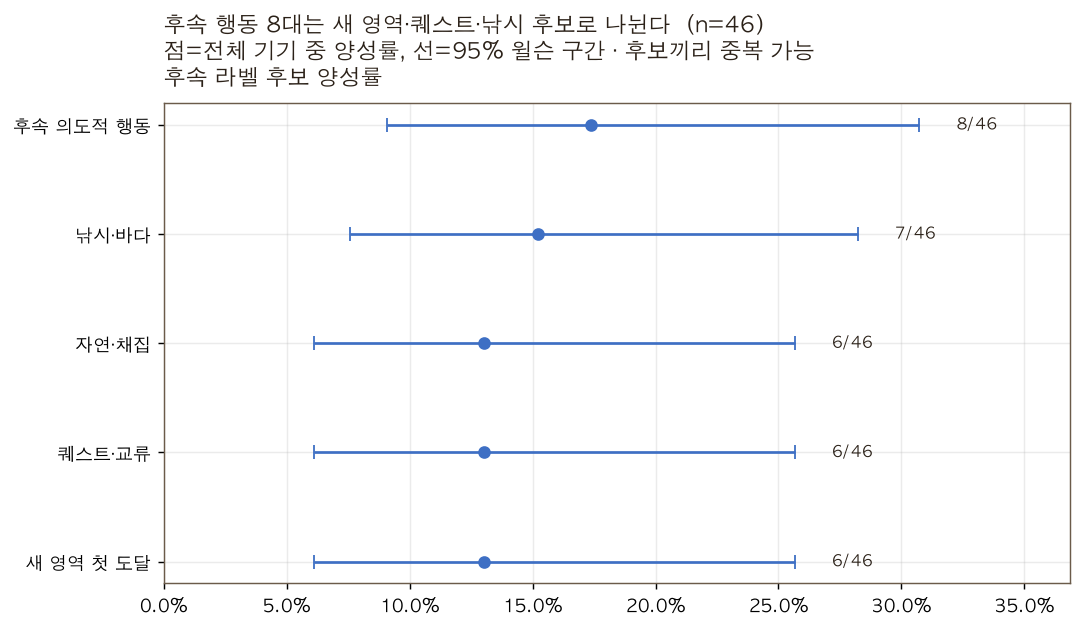

In [3]:
target_rows = [
    ('후속 의도적 행동', 'later_active', '전체 후속 행동'),
    ('새 영역 첫 도달', 'later_new_area', '추천/지역 안내 후보'),
    ('퀘스트·교류', 'later_quest_social', '퀘스트 유도 후보'),
    ('낚시·바다', 'later_fishing_sea', '낚시/바다 유도 후보'),
    ('자연·채집', 'later_nature', '기본 반복 행동 후보'),
]
targets = pd.DataFrame([
    {
        '라벨 후보': label,
        '설명': desc,
        '양성 기기': int(d[col].sum()),
        '전체 기기': len(d),
        '양성률': float(d[col].mean()),
    }
    for label, col, desc in target_rows
])
targets[['95% 하한', '95% 상한']] = [wilson(k, len(d)) for k in targets['양성 기기']]
targets['modeling_readiness_flag'] = np.where(targets['양성 기기'] < 10, 'positive<10', 'baseline_possible')
targets.to_csv(OUT / 'later_target_summary.csv', index=False)
display(targets)

plot = targets.sort_values('양성 기기')
fig, ax = R.new(
    '후속 행동 8대는 새 영역·퀘스트·낚시 후보로 나뉜다',
    len(d),
    sub='점=전체 기기 중 양성률, 선=95% 윌슨 구간 · 후보끼리 중복 가능',
    ylab='후속 라벨 후보 양성률',
    figsize=(9, 4.8),
)
y = range(len(plot))
ax.errorbar(
    plot['양성률'],
    list(y),
    xerr=[plot['양성률'] - plot['95% 하한'], plot['95% 상한'] - plot['양성률']],
    fmt='o',
    color=R.PALETTE[1],
    capsize=4,
)
ax.set_yticks(list(y), plot['라벨 후보'])
ax.set_xlim(0, max(plot['95% 상한']) * 1.2)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1))
for i, (_, row) in enumerate(plot.iterrows()):
    ax.text(row['95% 상한'] + 0.015, i, f"{int(row['양성 기기'])}/{len(d)}", va='center', fontsize=9)
chart_targets = R.save(fig, ax, 'g3_toss_later_target_summary', zero_base=False)
print(R.check(chart_targets))
display(R.show(chart_targets))


## 4. 2번 — 첫 10분 행동 6회 이상 집단 안 보기

초반 행동 6회 이상 17대를 한 덩어리로 보지 않고, 초반 도달 영역과 후속 목표를 같이 본다. 이 집단도 양성은 6대뿐이라 안정적인 세그먼트 규칙으로 쓰지 않는다.

In [4]:
deep = d[d.early_action_segment == '6회 이상'].copy()
deep_summary = pd.DataFrame({
    '항목': [
        '기기 수', '후속 행동', '새 영역 도달', '퀘스트·교류 후속 도달',
        '낚시·바다 후속 도달', '자연·채집 후속 도달',
        '초반 자연·채집 도달', '초반 퀘스트·교류 도달', '초반 낚시·바다 도달'
    ],
    '기기': [
        len(deep),
        int(deep.later_active.sum()),
        int(deep.later_new_area.sum()),
        int(deep.later_quest_social.sum()),
        int(deep.later_fishing_sea.sum()),
        int(deep.later_nature.sum()),
        int((deep.early_nature_events > 0).sum()),
        int((deep.early_quest_social_events > 0).sum()),
        int((deep.early_fishing_sea_events > 0).sum()),
    ],
})
deep_summary.to_csv(OUT / 'early_6plus_profile.csv', index=False)
display(deep_summary)

deep_cross = deep.groupby(['early_area_segment', 'early_connection_segment'], as_index=False).agg(
    devices=('device_label', 'size'),
    later_active_devices=('later_active', 'sum'),
    later_new_area_devices=('later_new_area', 'sum'),
    later_quest_social_devices=('later_quest_social', 'sum'),
    later_fishing_sea_devices=('later_fishing_sea', 'sum'),
)
deep_cross.to_csv(OUT / 'early_6plus_cross_segments.csv', index=False)
display(deep_cross)


,항목,기기
0,기기 수,17
1,후속 행동,6
2,새 영역 도달,4
3,퀘스트·교류 후속 도달,6
4,낚시·바다 후속 도달,6
5,자연·채집 후속 도달,6
6,초반 자연·채집 도달,17
7,초반 퀘스트·교류 도달,14
8,초반 낚시·바다 도달,4


,early_area_segment,early_connection_segment,devices,later_active_devices,later_new_area_devices,later_quest_social_devices,later_fishing_sea_devices
0,1개,연결 실패 기록,1,0,0,0,0
1,2개 이상,연결 성공만 기록,5,4,3,4,4
2,2개 이상,연결 실패 기록,2,1,1,1,1
3,2개 이상,연결 이벤트 없음,9,1,0,1,1


g3_toss_early6_later_targets.png  1019x611px


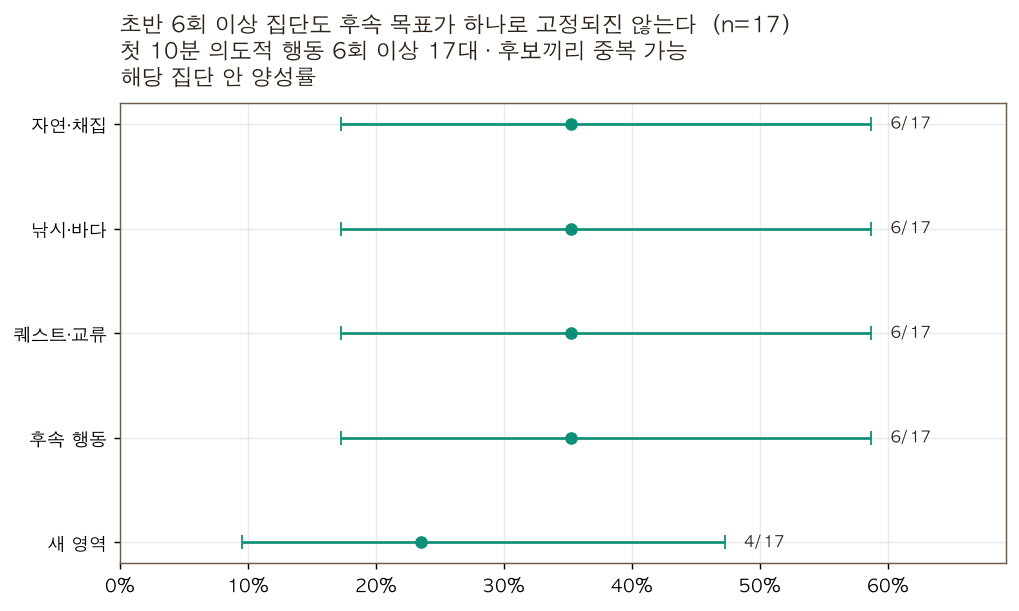

In [5]:
deep_plot = pd.DataFrame([
    ('후속 행동', int(deep.later_active.sum())),
    ('새 영역', int(deep.later_new_area.sum())),
    ('퀘스트·교류', int(deep.later_quest_social.sum())),
    ('낚시·바다', int(deep.later_fishing_sea.sum())),
    ('자연·채집', int(deep.later_nature.sum())),
], columns=['후속 목표', '기기'])
deep_plot['비율'] = deep_plot['기기'] / len(deep)
deep_plot[['95% 하한', '95% 상한']] = [wilson(k, len(deep)) for k in deep_plot['기기']]
plot = deep_plot.sort_values('기기')

fig, ax = R.new(
    '초반 6회 이상 집단도 후속 목표가 하나로 고정되진 않는다',
    len(deep),
    sub='첫 10분 의도적 행동 6회 이상 17대 · 후보끼리 중복 가능',
    ylab='해당 집단 안 양성률',
    figsize=(8.8, 4.6),
)
y = range(len(plot))
ax.errorbar(
    plot['비율'],
    list(y),
    xerr=[plot['비율'] - plot['95% 하한'], plot['95% 상한'] - plot['비율']],
    fmt='o',
    color=R.PALETTE[2],
    capsize=4,
)
ax.set_yticks(list(y), plot['후속 목표'])
ax.set_xlim(0, max(plot['95% 상한']) * 1.18)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1))
for i, (_, row) in enumerate(plot.iterrows()):
    ax.text(row['95% 상한'] + 0.015, i, f"{int(row['기기'])}/{len(deep)}", va='center', fontsize=9)
chart_deep = R.save(fig, ax, 'g3_toss_early6_later_targets', zero_base=False)
print(R.check(chart_deep))
display(R.show(chart_deep))


## 5. 3번 — 후속 행동 8대 공통점 감사

양성 8대가 특정 날짜나 깊은 플레이 꼬리에 몰리면 라벨로 쓰기 어렵다. 여기서는 원시 ID 없이 날짜·초반 깊이·연결 상태·후속 행동량 집중만 본다.

In [6]:
pos = d[d.later_active].copy()
positive_segments = pd.concat([
    pos.groupby('first_toss_day').size().rename_axis('축값').reset_index(name='양성 기기').assign(축='첫 토스 관측일'),
    pos.groupby('early_action_segment').size().rename_axis('축값').reset_index(name='양성 기기').assign(축='초반 행동량'),
    pos.groupby('early_connection_segment').size().rename_axis('축값').reset_index(name='양성 기기').assign(축='초반 연결 상태'),
], ignore_index=True)
positive_segments['전체 양성 대비'] = positive_segments['양성 기기'] / len(pos)
positive_segments.to_csv(OUT / 'positive_commonality_segments.csv', index=False)

positive_rows = pos[[
    'device_label', 'first_toss_day', 'device', 'early_action_segment',
    'early_area_segment', 'early_connection_segment', 'later_actions',
    'later_new_area', 'later_quest_social', 'later_fishing_sea', 'later_nature'
]].sort_values('later_actions', ascending=False)
positive_rows.to_csv(OUT / 'positive_anonymous_rows.csv', index=False)

display(positive_segments)
display(positive_rows)
print('양성 8대 중 후속 행동 이벤트 상위 3대 비중:', f"{positive_rows.later_actions.head(3).sum() / positive_rows.later_actions.sum():.1%}")


,축값,양성 기기,축,전체 양성 대비
0,2026-09-04,5,첫 토스 관측일,0.625
1,2026-09-05,2,첫 토스 관측일,0.250
2,2026-09-09,1,첫 토스 관측일,0.125
3,0회,2,초반 행동량,0.250
4,6회 이상,6,초반 행동량,0.750
5,연결 성공만 기록,5,초반 연결 상태,0.625
6,연결 실패 기록,1,초반 연결 상태,0.125
7,연결 이벤트 없음,2,초반 연결 상태,0.250


,device_label,first_toss_day,device,early_action_segment,early_area_segment,early_connection_segment,later_actions,later_new_area,later_quest_social,later_fishing_sea,later_nature
3,D004,2026-09-05,mobile,6회 이상,2개 이상,연결 실패 기록,755,True,True,True,True
0,D001,2026-09-04,mobile,6회 이상,2개 이상,연결 성공만 기록,753,True,True,True,True
4,D005,2026-09-04,mobile,6회 이상,2개 이상,연결 성공만 기록,319,True,True,True,True
17,D018,2026-09-04,mobile,6회 이상,2개 이상,연결 성공만 기록,317,True,True,True,True
5,D006,2026-09-05,mobile,6회 이상,2개 이상,연결 성공만 기록,182,False,True,True,True
2,D003,2026-09-09,mobile,6회 이상,2개 이상,연결 이벤트 없음,105,False,True,True,True
10,D011,2026-09-04,mobile,0회,0개,연결 성공만 기록,14,True,False,True,False
11,D012,2026-09-04,desktop,0회,0개,연결 이벤트 없음,1,True,False,False,False


양성 8대 중 후속 행동 이벤트 상위 3대 비중: 74.7%


g3_toss_positive_by_first_day.png  917x600px


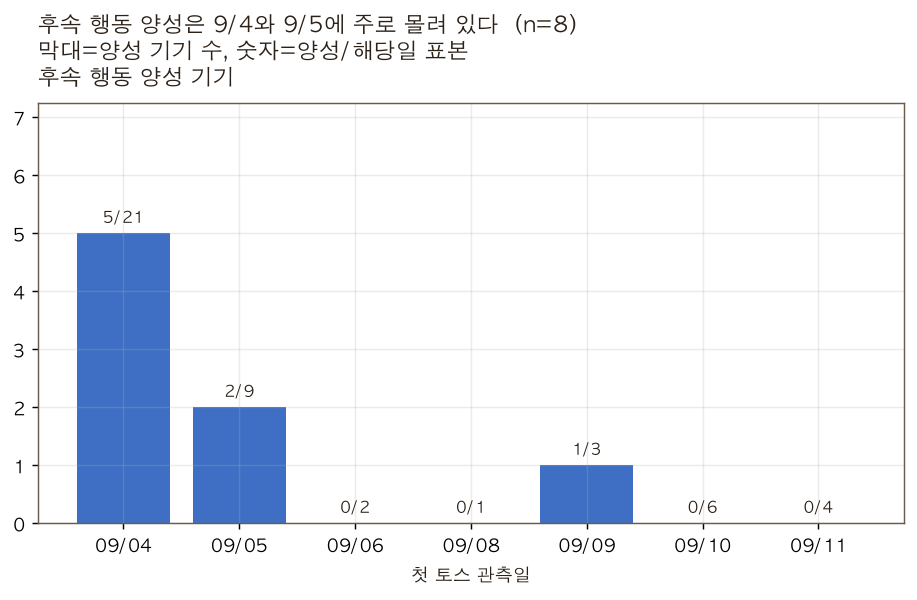

In [7]:
date_counts = d.groupby('first_toss_day', as_index=False).agg(
    devices=('device_label', 'size'),
    positives=('later_active', 'sum'),
)
date_counts['positive_rate'] = date_counts.positives / date_counts.devices
date_counts.to_csv(OUT / 'positive_by_first_toss_day.csv', index=False)

fig, ax = R.new(
    '후속 행동 양성은 9/4와 9/5에 주로 몰려 있다',
    int(d.later_active.sum()),
    sub='막대=양성 기기 수, 숫자=양성/해당일 표본',
    ylab='후속 행동 양성 기기',
    figsize=(8.6, 4.2),
)
x = range(len(date_counts))
bars = ax.bar(x, date_counts.positives, color=R.PALETTE[1])
ax.set_xticks(list(x), pd.to_datetime(date_counts.first_toss_day).dt.strftime('%m/%d'))
for i, row in date_counts.iterrows():
    ax.text(i, row.positives + 0.18, f"{int(row.positives)}/{int(row.devices)}", ha='center', fontsize=9)
ax.set_ylim(0, max(date_counts.positives) * 1.45)
ax.set_xlabel('첫 토스 관측일')
chart_pos_date = R.save(fig, ax, 'g3_toss_positive_by_first_day')
print(R.check(chart_pos_date))
display(R.show(chart_pos_date))


## 6. 4번 — `새 영역 첫 도달` 라벨 만들기

`새 영역 첫 도달`은 첫 10분에 기록되지 않은 활동 영역이 10분 이후~24시간에 처음 나타난 경우다. 단순 재방문보다 게임 안 추천 로직에 더 가깝다. 예를 들어 초반에 자연·채집만 하던 기기가 이후 낚시·바다나 퀘스트·교류로 넓어지면 양성이다.

In [8]:
new_area_cols = [
    ('자연·채집', 'later_new_nature_events'),
    ('낚시·바다', 'later_new_fishing_sea_events'),
    ('퀘스트·교류', 'later_new_quest_social_events'),
    ('제작·집', 'later_new_craft_home_events'),
    ('고급 콘텐츠', 'later_new_advanced_events'),
]
new_targets = pd.DataFrame([
    {
        '새 영역 후보': label,
        '도달 기기': int((d[col] > 0).sum()),
        '전체 기기': len(d),
        '도달률': float((d[col] > 0).mean()),
    }
    for label, col in new_area_cols
])
new_targets[['95% 하한', '95% 상한']] = [wilson(k, len(d)) for k in new_targets['도달 기기']]
new_targets.to_csv(OUT / 'new_area_target_summary.csv', index=False)

new_by_early = d.groupby('early_action_segment', as_index=False).agg(
    devices=('device_label', 'size'),
    new_area_devices=('later_new_area', 'sum'),
    later_active_devices=('later_active', 'sum'),
)
new_by_early['new_area_rate'] = new_by_early.new_area_devices / new_by_early.devices
new_by_early.to_csv(OUT / 'new_area_by_early_action_segment.csv', index=False)
display(new_targets)
display(new_by_early)


,새 영역 후보,도달 기기,전체 기기,도달률,95% 하한,95% 상한
0,자연·채집,0,46,0.000000,-6.938894e-18,0.077076
1,낚시·바다,4,46,0.086957,3.433531e-02,0.203249
2,퀘스트·교류,1,46,0.021739,3.847755e-03,0.113356
3,제작·집,3,46,0.065217,2.242745e-02,0.175030
4,고급 콘텐츠,2,46,0.043478,1.200519e-02,0.145325


,early_action_segment,devices,new_area_devices,later_active_devices,new_area_rate
0,0회,22,2,2,0.090909
1,1~5회,7,0,0,0.0
2,6회 이상,17,4,6,0.235294


g3_toss_new_area_targets.png  1044x611px


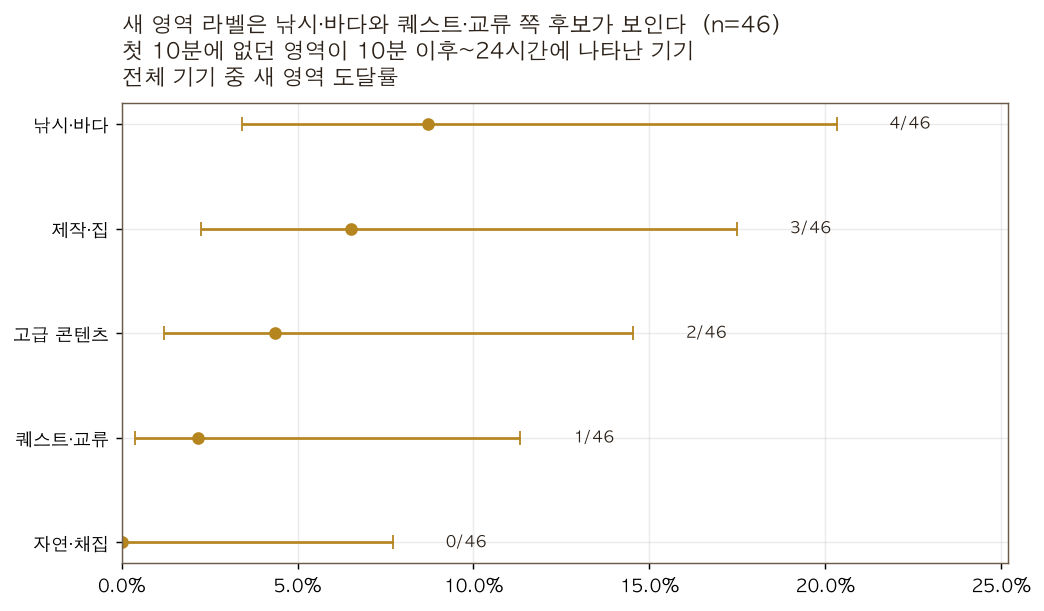

In [9]:
plot = new_targets.sort_values('도달 기기')
fig, ax = R.new(
    '새 영역 라벨은 낚시·바다와 퀘스트·교류 쪽 후보가 보인다',
    len(d),
    sub='첫 10분에 없던 영역이 10분 이후~24시간에 나타난 기기',
    ylab='전체 기기 중 새 영역 도달률',
    figsize=(8.8, 4.6),
)
y = range(len(plot))
ax.errorbar(
    plot['도달률'],
    list(y),
    xerr=[plot['도달률'] - plot['95% 하한'], plot['95% 상한'] - plot['도달률']],
    fmt='o',
    color=R.PALETTE[3],
    capsize=4,
)
ax.set_yticks(list(y), plot['새 영역 후보'])
ax.set_xlim(0, max(plot['95% 상한']) * 1.24)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1))
for i, (_, row) in enumerate(plot.iterrows()):
    ax.text(row['95% 상한'] + 0.015, i, f"{int(row['도달 기기'])}/{len(d)}", va='center', fontsize=9)
chart_new_area = R.save(fig, ax, 'g3_toss_new_area_targets', zero_base=False)
print(R.check(chart_new_area))
display(R.show(chart_new_area))


## 7. 그래서 크기가 얼마나 되나

후속 행동 양성은 8대다. 그중 새 영역 첫 도달은 6대, 퀘스트·교류 후속 도달은 6대, 낚시·바다 후속 도달은 7대다. 숫자만 보면 `새 영역`과 `낚시·바다`가 게임 안 유도 로직으로 가장 자연스럽지만, 둘 다 양성 수가 한 자리수라 모델 목표로 확정하기엔 이르다.

초반 행동 6회 이상 집단은 17대이고, 이 중 후속 행동은 6대다. 이 집단 안에서도 새 영역 4대, 퀘스트·교류 6대, 낚시·바다 6대, 자연·채집 6대로 후보가 겹친다. 따라서 “초반 행동이 깊으면 무조건 특정 콘텐츠를 추천한다” 같은 규칙은 아직 만들 수 없다.

## 8. 이 숫자로 말할 수 없는 것

- `새 영역 첫 도달`은 추천 효과가 아니다. 추천을 하지 않아도 자연스럽게 새 영역으로 간 기록이다.
- 날짜가 짧고 양성이 8대라 9/4·9/5 집중을 유입 품질이나 업데이트 효과로 분리할 수 없다.
- 후속 행동 이벤트 수는 소수 기기에 크게 몰린다. 이벤트 수를 곧 체류시간이나 만족도로 읽지 않는다.
- `platform=toss` 전에 떠난 사람은 이 표본에 없다. 토스 전체 진입 실패 분석은 별도다.
- 미표식 내부 사용자 가능성이 남아 있다. 양성 8대 중 일부가 내부 점검이면 라벨 후보 전체가 흔들린다.

In [10]:
assumptions = {
    'analysis': 'g3-toss-later-target-label-eda',
    'date': '2026-09-15',
    'source': 'BigQuery GA4 daily export, 2026-09-04 through 2026-09-12 KST',
    'gate': 'G3 label target EDA',
    'result': 'candidate_targets_documented_no_modeling',
    'checks': {
        'device_rows': int(len(d)),
        'later_active_devices': int(d.later_active.sum()),
        'new_area_devices': int(d.later_new_area.sum()),
        'quest_social_later_devices': int(d.later_quest_social.sum()),
        'fishing_sea_later_devices': int(d.later_fishing_sea.sum()),
        'feature_boundary_violations': int(d.feature_boundary_violations.sum()),
        'label_boundary_violations': int(d.label_boundary_violations.sum()),
    },
    'candidate_next_label': {
        'name': 'later_new_area',
        'definition': 'A device reaches at least one deliberate-play area in the 10m-to-24h label window that was absent in the first 10m feature window.',
        'positive_devices': int(d.later_new_area.sum()),
        'status': 'candidate_only',
    },
    'assumptions': [
        {
            'assumption': 'Splitting later actions by area better matches in-game guidance than a generic later-active label.',
            'confidence': 'medium',
            'impact_if_wrong': 'medium',
            'validation': 'Needs product agreement on which next action is worth guiding.',
            'result': 'candidate_only',
        },
        {
            'assumption': 'Later new area is observable without label leakage from the first 10m window.',
            'confidence': 'high',
            'impact_if_wrong': 'critical',
            'validation': 'Feature and label boundary violations are zero.',
            'result': 'passed',
        },
        {
            'assumption': 'The current eight later-active devices are representative enough to choose a target.',
            'confidence': 'low',
            'impact_if_wrong': 'critical',
            'validation': 'Needs more Toss devices or tester/deep-device sensitivity checks.',
            'result': 'open',
        },
    ],
}
(OUT / 'assumptions.json').write_text(json.dumps(assumptions, ensure_ascii=False, indent=2), encoding='utf-8')
display(Markdown('```json\n' + json.dumps(assumptions, ensure_ascii=False, indent=2) + '\n```'))


```json
{
  "analysis": "g3-toss-later-target-label-eda",
  "date": "2026-09-15",
  "source": "BigQuery GA4 daily export, 2026-09-04 through 2026-09-12 KST",
  "gate": "G3 label target EDA",
  "result": "candidate_targets_documented_no_modeling",
  "checks": {
    "device_rows": 46,
    "later_active_devices": 8,
    "new_area_devices": 6,
    "quest_social_later_devices": 6,
    "fishing_sea_later_devices": 7,
    "feature_boundary_violations": 0,
    "label_boundary_violations": 0
  },
  "candidate_next_label": {
    "name": "later_new_area",
    "definition": "A device reaches at least one deliberate-play area in the 10m-to-24h label window that was absent in the first 10m feature window.",
    "positive_devices": 6,
    "status": "candidate_only"
  },
  "assumptions": [
    {
      "assumption": "Splitting later actions by area better matches in-game guidance than a generic later-active label.",
      "confidence": "medium",
      "impact_if_wrong": "medium",
      "validation": "Needs product agreement on which next action is worth guiding.",
      "result": "candidate_only"
    },
    {
      "assumption": "Later new area is observable without label leakage from the first 10m window.",
      "confidence": "high",
      "impact_if_wrong": "critical",
      "validation": "Feature and label boundary violations are zero.",
      "result": "passed"
    },
    {
      "assumption": "The current eight later-active devices are representative enough to choose a target.",
      "confidence": "low",
      "impact_if_wrong": "critical",
      "validation": "Needs more Toss devices or tester/deep-device sensitivity checks.",
      "result": "open"
    }
  ]
}
```

## 9. 판정

**G3 라벨 후보 EDA 통과, 모델링 보류.** 1~4번은 확인했다. 다음에 모델링으로 가려면 먼저 목표 라벨을 하나 정해야 한다. 현재 숫자만 보면 `새 영역 첫 도달`이 게임 퀘스트·즐길거리 유도 로직과 가장 잘 맞는 후보지만, 양성 6대라 아직 후보일 뿐이다. 여기서 멈춘다.